# CANADA: LINCS Filtering

# Packages

In [18]:
from cmapPy.pandasGEXpress import parse
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import seaborn as sns

import matplotlib.pyplot as plt

# Directories

In [3]:
# Input
INPUT = Path('D:/DDesktop/_work/data/canada/input')
# Output
OUTPUT = Path('D:/DDesktop/_work/data/canada/output')

# LINCS data
LINCS_DATA = str(INPUT / 'LDS-1481/LDS-1481_1.0.gctx')                             # Changed to string for cmapPy
#LINCS_DATA = INPUT / 'LDS-1481/LDS-1481_1.0.gctx'
# LINCS info
LINCS_INFO = OUTPUT / 'df_lincs_info.pkl'
# Gene data
LINCS_GENES = OUTPUT / 'df_lincs_genes.pkl'
# Perturbagen data
LINCS_PERTURBAGEN = OUTPUT / 'df_lincs_perturbagens.pkl'
# Landmark data
LINCS_LANDMARK = OUTPUT / 'mapped_landmark.txt'

# Functions

In [75]:
def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()

def file_to_list(path):
    '''
    Converts a .txt file to a list
    '''

    with open(f'{path}', 'r', encoding = 'utf-8') as f:
        list_file = [line.strip() for line in f]
    
    return list_file

def filter_lincs_data(path_data: str,
                      path_info: str, 
                      path_genes: str,
                      path_perturbagens: str,
                      path_landmark: str,
                      list_cells: list, 
                      list_timepoints: list, 
                      list_doses: list, 
                      num_drugs: int, 
                      list_specific: list = []) -> pd.DataFrame:
      '''
      Takes various inputs to filter LINCS1000 expression data.

      Assumes a variety of data files are loaded for access e.g. `df_lincs_info`, `df_lincs_genes` etc.
      '''

      print('Loading relevant datasets...')

      # Load data info
      df_info = pickle_load(path_info)
      # Load perturbagen data
      df_perturbagen = pickle_load(path_perturbagens)  
      # Load gene data
      df_genes = pickle_load(path_genes)
      # Load landmark genes
      list_landmark = file_to_list(path_landmark)

      print(f'Filtering LINCS data for...')
      print(f'  > Cell line(s): {list_cells}')
      print(f'  > Timepoint(s): {list_timepoints}')
      print(f'  > Dose(s): {list_doses}')

      # Filter info for search terms
      df_filter = df_info[(df_info['cell_id'].isin(list_cells)) &
                          (df_info['pert_time'].isin(list_timepoints)) &
                          (df_info['pert_dose'].isin(list_doses))]
      
      print('LINCS data filtered')
      print('')
      print('Extracting signature IDs...')

      # Extract signature IDs
      list_signature_ids = df_filter['sig_id'].tolist()
      num_sig_ids = len(list_signature_ids)

      print(f'{num_sig_ids:,} signature IDs found after filtering')
      print('')
      print('Extracting CD data...')

      # Filter data
      df = parse.parse(path_data, cid = list_signature_ids).data_df

      print('CD data extracted')
      print('')
      print('Extracting metadata...')
      
      # Extract column IDs
      list_cids = list(df.columns)
      # Initialise dataframe
      df_meta = pd.DataFrame(list_cids, columns = ['cid'])
      # Copy column
      df_meta['metadata'] = df_meta['cid']
      # Extract perturbagen ID
      df_meta['metadata'] = df_meta['metadata'].str.replace(r'-(?:[^-]+-){2}[^-]+(?=:\d+$)', '', regex = True)
      # Split metadata column
      df_meta[['data', 'perturbagen_id', 'dose']] = df_meta['metadata'].str.split(':', expand = True)
      # Split data column
      df_meta[['dataset', 'cell_line', 'timepoint']] = df_meta['data'].str.split('_', expand = True)
      # Drop columns
      df_meta.drop(columns = ['metadata', 'data'], inplace = True)
      # Merge with perturbagen data
      df_meta = pd.merge(df_meta, df_perturbagen, how = 'left', on = 'perturbagen_id')

      print('Metadata extracted')
      print('')
      print('Merging metadata...')

      # Reset index
      df.reset_index(inplace = True)
      # Assert datatypes
      df['rid'] = df['rid'].astype(int)
      df_genes['rid'] = df_genes['rid'].astype(int)
      # Merge data
      df = pd.merge(df, df_genes[['rid', 'gene_name', 'gene_desc', 'landmark']], how = 'left', on = 'rid')
      # Melt on CD values
      df = df.melt(id_vars = ['rid', 'gene_name', 'gene_desc', 'landmark'], value_vars = list_cids, var_name = 'cid', value_name = 'value')
      # Merge with metadata
      df = pd.merge(df, df_meta, how = 'left', on = 'cid')
      # Reorder columns
      df = df[['cid', 'dataset', 'cell_line', 'perturbagen_id', 'perturbagen_name', 'dose', 'timepoint', 'rid', 'gene_name', 'gene_desc', 'landmark', 'value']]
      # Rename columns
      df.rename(columns = {'rid' : 'gene_id', 'value' : 'cd'}, inplace = True)

      print('Metadata merged')
      print('')
      print('Filtering for drugs w/ data at all timepoints...')

      # Get number of perturbagen IDs
      num_unique_ids = len(pd.unique(df['perturbagen_id']))
      # Get number of timepoints per ID
      df_grouped = df.groupby(by = 'perturbagen_id')['timepoint'].nunique()
      # Get number of desired timepoints
      num_timepoints = len(list_timepoints)
      # Get entries with desired timepoints
      list_timepoint_ids = df_grouped[df_grouped == num_timepoints].index.tolist()
      
      # Get number of retained perturbagens
      num_timepoint_ids = len(list_timepoint_ids)
      # Get % of retained perturbagens
      percent_timepoint_ids = num_timepoint_ids / num_unique_ids * 100

      print(f'{percent_timepoint_ids:.2f}% of perturbagens ({num_timepoint_ids:,}/{num_unique_ids:,}) found w/ data at all desired timepoints ({list_timepoints})')

      # Filter for timepoint perturbagen IDs
      df = df[df['perturbagen_id'].isin(list_timepoint_ids)]
      # Get retained perturbagen names
      list_timepoint_names = list(pd.unique(df['perturbagen_name']))

      print(f'Data filtered for drugs w/ data at all timepoints')
      print(f'Checking for data to sample...')
      
      # Get number of drugs to randomly sample
      num_sample = num_drugs - len(list_specific)

      # Check for specified drugs parameter
      if len(list_specific) > 0:
        print(f'{len(list_specific)} drugs specifically requested')
        # Check if any specified drugs are in timepoint data
        specific_in_timepoint_data = [name for name in list_timepoint_names if name in list_specific]
        # Check length of specified drugs in timepoint data
        if len(specific_in_timepoint_data) > 0:
            print(f'{len(specific_in_timepoint_data)} of specific drugs found')
            # If so, split data into those drugs and all others
            df_specific = df[df['perturbagen_name'].isin(specific_in_timepoint_data)]
            df_non_specific = df[~df['perturbagen_name'].isin(specific_in_timepoint_data)]
        else:
            print(f'None of the specified drugs found in data')
            df_non_specific = df
            df_specific = pd.DataFrame()
            
      else:
        df_non_specific = df
        df_specific = pd.DataFrame()
        
      num_non_specific = len(pd.unique(df_non_specific['perturbagen_id']))

      # Check length of df_non_specific against num_sample
      if num_sample > num_non_specific:
        print(f'Desired number of randomly sampled perturbagens ({num_sample}) > available timepoint perturbagens')
        print('All data retained')
        df_final = df_non_specific
      elif num_sample == num_non_specific:
        print(f'Desired number of randomly sampled perturbagens ({num_sample}) == available timepoint perturbagens')
        print('All data retained')
        df_final = df_non_specific
      elif num_sample < num_non_specific:
        print(f'Desired number of randomly sampled perturbagens ({num_sample}) < available timepoint perturbagens')
        print('Randomly sampling perturbagen data...')
        # Get list of randomly sampled perturbagen IDs
        list_random = df_non_specific['perturbagen_id'].drop_duplicates().sample(n = num_sample)
        # Filter dataframe
        df_non_specific = df_non_specific[df_non_specific['perturbagen_id'].isin(list_random)]
        # Combine dataframes
        df_final = pd.concat([df_non_specific, df_specific], ignore_index = True)
        print('Data sampled')
    
      print('')
      print('Filtering sampled timepoint data for landmark genes...')
      
      df_final = df_final[df_final['gene_name'].isin(list_landmark)]

      print('Landmark data filtered')
    
      print('Filtering complete')
    
      return df_final

# Data Filtering

## Variables

In [ ]:
CELL_LINES = ['HT29']
TIMEPOINTS = [6, 24]
DOSES = [10]
N_DRUGS = 500
SPECIFIC_DRUGS = ['narciclasine']

# Filtering

In [91]:
# Filter data
df_lincs_filter = filter_lincs_data(path_data = LINCS_DATA,
                                    path_info = LINCS_INFO,
                                    path_genes = LINCS_GENES,
                                    path_perturbagens = LINCS_PERTURBAGEN,
                                    path_landmark = LINCS_LANDMARK,
                                    list_cells = CELL_LINES,
                                    list_timepoints = TIMEPOINTS,
                                    list_doses = DOSES,
                                    num_drugs = N_DRUGS,
                                    list_specific = SPECIFIC_DRUGS)

# Save data
pickle_save(OUTPUT / 'df_lincs_filter.pkl', df_lincs_filter)
# Show data
df_lincs_filter.head()

Loading relevant datasets...
Filtering LINCS data for...
  > Cell line(s): ['HT29']
  > Timepoint(s): [6, 24]
  > Dose(s): [10]
LINCS data filtered

Extracting signature IDs...
7,102 signature IDs found after filtering

Extracting CD data...


c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\cmapPy\pandasGEXpress\parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\cmapPy\pandasGEXpress\parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


CD data extracted

Extracting metadata...
Metadata extracted

Merging metadata...
Metadata merged

Filtering for drugs w/ data at all timepoints...
18.36% of perturbagens (938/5,108) found w/ data at all desired timepoints ([6, 24])
Data filtered for drugs w/ data at all timepoints
Checking for data to sample...
2 drugs specifically requested
1 of specific drugs found
Desired number of randomly sampled perturbagens (498) < available timepoint perturbagens
Randomly sampling perturbagen data...
Data sampled

Filtering sampled timepoint data for landmark genes...
Landmark data filtered
Filtering complete


,cid,dataset,cell_line,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,gene_name,gene_desc,landmark,cd
0,CPC005_HT29_6H:BRD-K51223576-001-01-3:10,CPC005,HT29,BRD-K51223576,AG-99,10,6H,5720,PSME1,proteasome activator subunit 1,1,-0.284185
1,CPC005_HT29_6H:BRD-K51223576-001-01-3:10,CPC005,HT29,BRD-K51223576,AG-99,10,6H,466,ATF1,activating transcription factor 1,1,0.067755
2,CPC005_HT29_6H:BRD-K51223576-001-01-3:10,CPC005,HT29,BRD-K51223576,AG-99,10,6H,6009,RHEB,Ras homolog enriched in brain,1,-0.300248
3,CPC005_HT29_6H:BRD-K51223576-001-01-3:10,CPC005,HT29,BRD-K51223576,AG-99,10,6H,2309,FOXO3,forkhead box O3,1,0.091755
4,CPC005_HT29_6H:BRD-K51223576-001-01-3:10,CPC005,HT29,BRD-K51223576,AG-99,10,6H,387,RHOA,ras homolog family member A,1,-0.627101


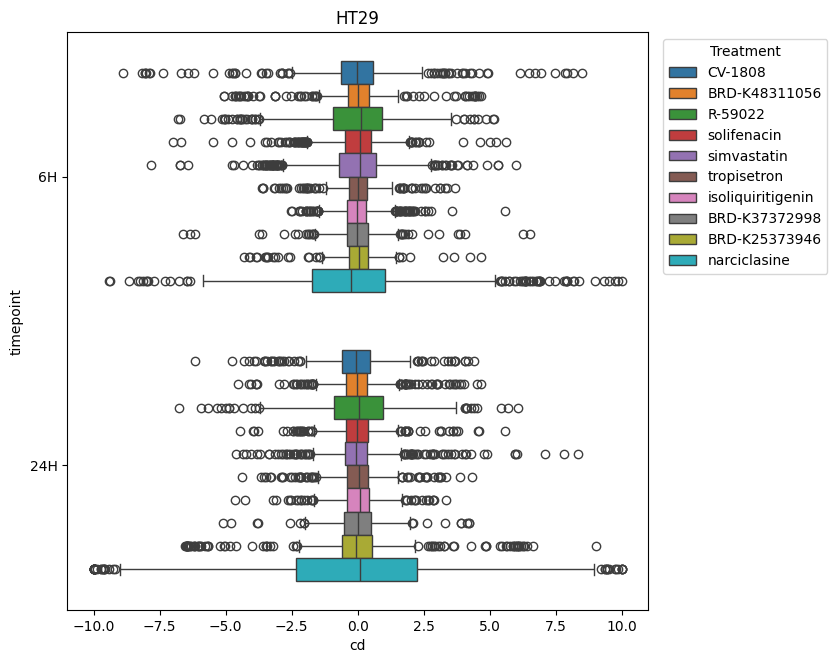

In [88]:
plt.figure(figsize = (7.5,7.5))
plt.title('HT29')
bp = sns.boxplot(df_lincs_filter, y = 'timepoint', x = 'cd', hue = 'perturbagen_name')
legend = bp.legend(title = 'Treatment',
                    bbox_to_anchor = (1.32, 1),
                    loc = 'upper right')